## Formula 1 Race Strategy Analytics!!

## Introduction

Formula 1 is not just a battle of speed — it is a game of strategy, timing, and decision-making. In modern racing, factors such as tire degradation, lap pace, track position, and pit stop timing often determine the outcome of a race more than raw speed alone.

This dataset contains lap-level Formula 1 race data, where each row represents a driver’s performance during a specific lap. The data captures important strategic elements such as tyre life, lap time changes, position changes, race progress, and pit stop behavior.

The primary objective of this analysis is to understand the factors that influence pit stop decisions and identify patterns that impact race strategy. Through exploratory data analysis, we aim to uncover how tire degradation and race conditions affect driver performance over time.

Eventually, this project will extend into Machine Learning to predict whether a driver is likely to pit on the next lap.

## Understanding the Dataset

Before performing any analysis, it is important to first understand the structure and quality of the dataset. A proper understanding of the data helps identify potential issues such as missing values, incorrect datatypes, or inconsistencies that could affect the analysis later.

In this section, we will explore:

* The size of the dataset
* Column information
* Datatype structure
* Missing values
* Duplicate records

## Importing Required Libraries

To perform data analysis and visualization, we first import the necessary Python libraries. These libraries will help with data manipulation, numerical operations, and visual exploration of racing patterns throughout the project.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)


## Loading the Dataset

After importing the required libraries, the next step is to load the dataset into the notebook. Before beginning deeper analysis, it is important to inspect the dataset and understand its overall structure.


In [42]:
# Loading the dataset
f1 = pd.read_csv("f1_strategy_dataset_v4.csv")

In [43]:
# Previewing the first 5 rows
f1.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [44]:
# Checking dataset dimensions
f1.shape

(101371, 16)

In [45]:
# Dataset information
f1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

## Initial Observations

From the dataset structure, several important observations can already be made.

The dataset contains more than 100,000 lap-level race observations, making it sufficiently detailed for exploratory analysis and predictive modeling. Most variables are numerical, which is useful for statistical analysis and machine learning applications.

The dataset also includes engineered racing metrics such as LapTime_Delta, Cumulative_Degradation, and Normalized_TyreLife, indicating that the data is designed to capture tire behavior, race pace changes, and strategic race conditions.

Additionally, most columns appear complete except for the Compound column, which contains a small number of missing values that may require further investigation during the data cleaning stage.

## Investigating Missing Values

Missing values can affect both analysis and machine learning performance if not handled properly. Before moving further, it is important to identify whether any variables contain incomplete information.

From the earlier dataset inspection, the Compound column appeared to contain some missing entries. In this step, we will examine missing values across all columns to better understand the extent of the issue.

In [46]:
# Checking missing values
f1.isnull().sum()

Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

In [47]:
# Checking duplicate rows
f1.duplicated().sum()

np.int64(0)

## How does tyre life impact lap performance?

## Visualizing Tyre Life vs Lap Time

To examine how tyre wear impacts performance, we will visualize the relationship between TyreLife and LapTime (s).

The objective is to observe whether lap times tend to increase as tyres age over a race stint. If a positive relationship exists, it could indicate the impact of tyre degradation on racing performance.

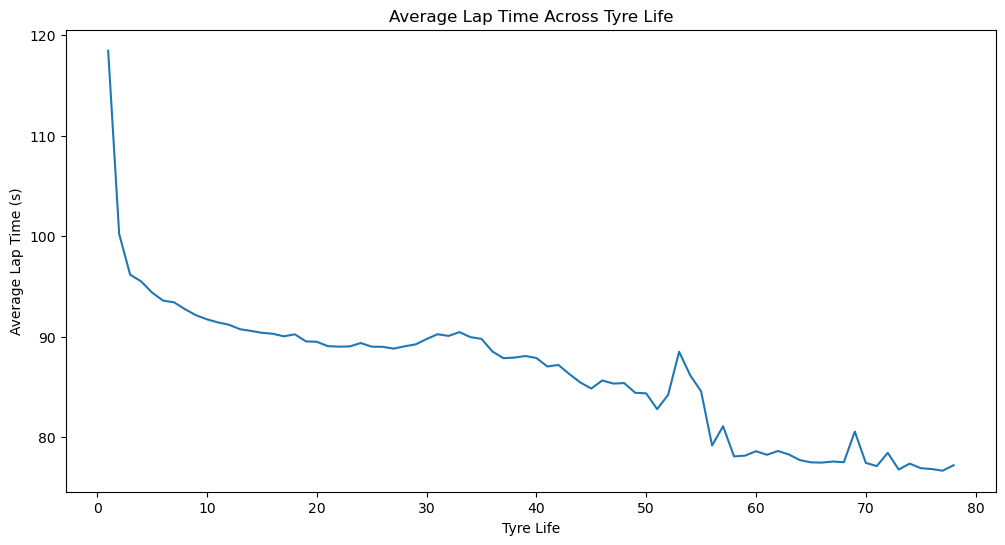

In [48]:
# Average lap time by tyre life
tyre_performance = (
    f1.groupby('TyreLife')['LapTime (s)']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=tyre_performance,
    x='TyreLife',
    y='LapTime (s)'
)

plt.title('Average Lap Time Across Tyre Life')
plt.xlabel('Tyre Life')
plt.ylabel('Average Lap Time (s)')

plt.show()

# Observation

The visualization shows that the relationship between tyre life and lap time is not as straightforward as initially expected. While tyre degradation is generally associated with slower lap times, the overall trend in the dataset does not show a continuous increase in lap times as tyre life increases.

In fact, average lap times appear to decrease during several stages of tyre life. This suggests that lap performance is influenced by multiple factors beyond tyre wear alone, such as fuel load reduction, race pace variation, track conditions, and tyre compound differences.

The chart highlights that tyre degradation cannot be analyzed in isolation using aggregated race data. A deeper analysis separating tyre compounds or race conditions may provide a clearer understanding of how tyre wear impacts performance over time.

## Analyzing Performance Across Tyre Life Stages

While the previous trend analysis provided a general overview of tyre life and lap performance, it did not clearly highlight how performance changes across different stages of tyre usage.

To make the analysis more interpretable, tyre life will now be grouped into broader intervals representing different phases of tyre wear. This allows us to compare lap time distributions across tyre life stages and identify whether performance variability increases as tyres age.

## Investigating Lap Time Distribution

The previous visualization showed that extreme lap time values are heavily affecting the readability of the analysis. Before continuing with tyre performance analysis, it is important to investigate the distribution of lap times and identify whether significant outliers exist in the dataset.

Understanding the presence of unusually high lap times is important because such values may represent pit stops, safety car conditions, race interruptions, or abnormal race events that can distort overall performance analysis

## Creating a Filtered Performance Dataset

The lap time distribution shows the presence of extreme outlier values that significantly affect visualization clarity and performance analysis.

Since these unusually high lap times are likely associated with non-racing events such as pit stops, safety car conditions, or interruptions, a filtered dataset will be created to focus specifically on realistic racing performance.

In [63]:
# Creating filtered dataset for performance analysis
f1_filtered = f1[f1['LapTime (s)'] < 200]

In [64]:
# Comparing dataset sizes

print("Original Dataset Shape :", f1.shape)
print("Filtered Dataset Shape :", f1_filtered.shape)

Original Dataset Shape : (101371, 17)
Filtered Dataset Shape : (101339, 17)


In [65]:
import plotly.express as px

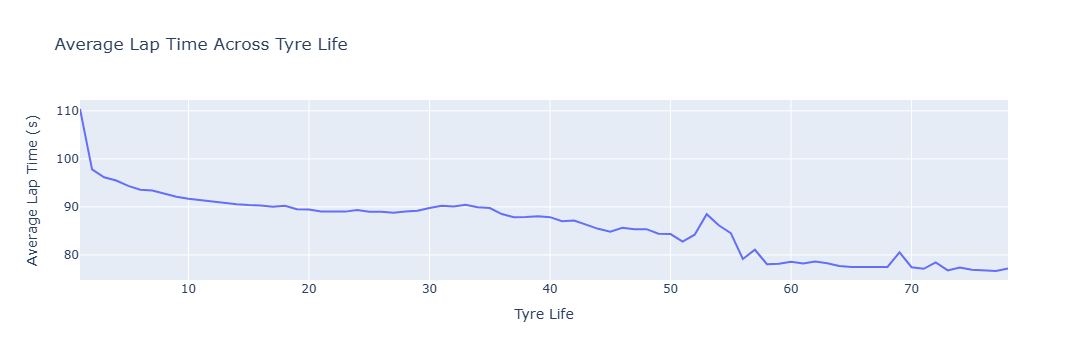

In [66]:
# Average lap time by tyre life
tyre_performance = (
    f1_filtered.groupby('TyreLife')['LapTime (s)']
    .mean()
    .reset_index()
)

fig = px.line(
    tyre_performance,
    x='TyreLife',
    y='LapTime (s)',
    title='Average Lap Time Across Tyre Life'
)

fig.update_layout(
    xaxis_title='Tyre Life',
    yaxis_title='Average Lap Time (s)',
    hovermode='x unified'
)

fig.show()

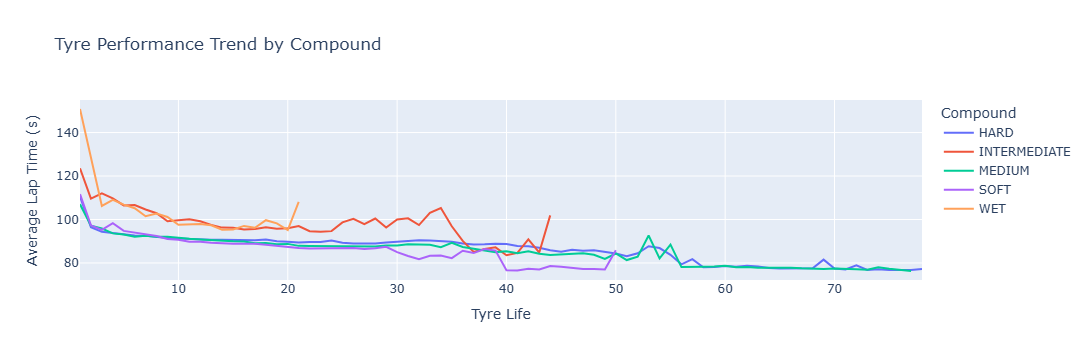

In [67]:
# Average lap time by tyre life and compound
compound_performance = (
    f1_filtered.groupby(['TyreLife', 'Compound'])['LapTime (s)']
    .mean()
    .reset_index()
)

fig = px.line(
    compound_performance,
    x='TyreLife',
    y='LapTime (s)',
    color='Compound',
    title='Tyre Performance Trend by Compound'
)

fig.update_layout(
    xaxis_title='Tyre Life',
    yaxis_title='Average Lap Time (s)',
    hovermode='x unified'
)

fig.show()

## Comparing Overall Performance Across Tyre Compounds

While trend-based analysis helps explore tyre behavior over time, it can sometimes make decision-making difficult due to overlapping patterns and race-level variability.

To simplify the comparison, we now shift the analysis toward overall compound-level performance. By comparing the average lap times of each tyre compound, we can more clearly identify which compounds tend to deliver faster or slower race pace overall.

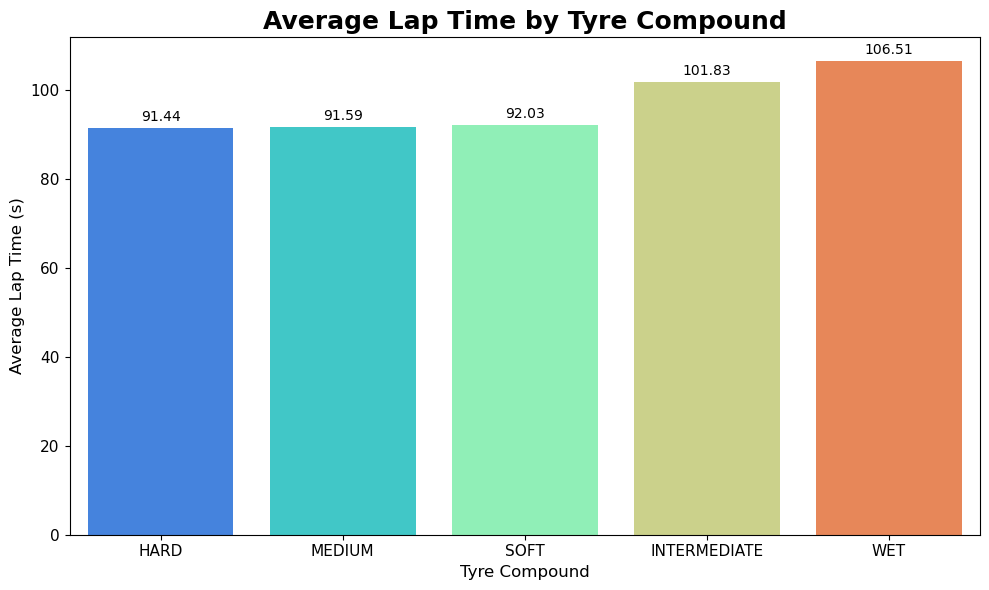

In [68]:
# Average lap time by tyre compound
compound_avg = (
    f1_filtered.groupby('Compound')['LapTime (s)']
    .mean()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=compound_avg,
    x='Compound',
    y='LapTime (s)',
    hue='Compound',
    palette='rainbow',
    legend=False
)

# Adding value labels
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=3)

plt.title(
    'Average Lap Time by Tyre Compound',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Tyre Compound', fontsize=12)
plt.ylabel('Average Lap Time (s)', fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()

plt.show()


The comparison included all tyre compounds, including WET and INTERMEDIATE tyres. However, these compounds are typically used during wet race conditions, where lap times are naturally slower due to reduced track grip and changing weather conditions.

To make the performance comparison more meaningful, the next analysis focuses only on dry tyre compounds (SOFT, MEDIUM, and HARD). This allows tyre performance to be evaluated under more comparable racing conditions.

In [69]:
# Filtering only dry tyre compounds
dry_tyres = f1_filtered[
    f1_filtered['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])
]

## Comparing Dry Tyre Performance Distribution

While average lap times provide a high-level comparison, they do not fully capture performance consistency and variability across tyre compounds.

To better understand dry tyre behavior, we now compare the lap time distributions of SOFT, MEDIUM, and HARD compounds. This helps evaluate:

* overall pace consistency
* spread of lap times
* stability across race stints

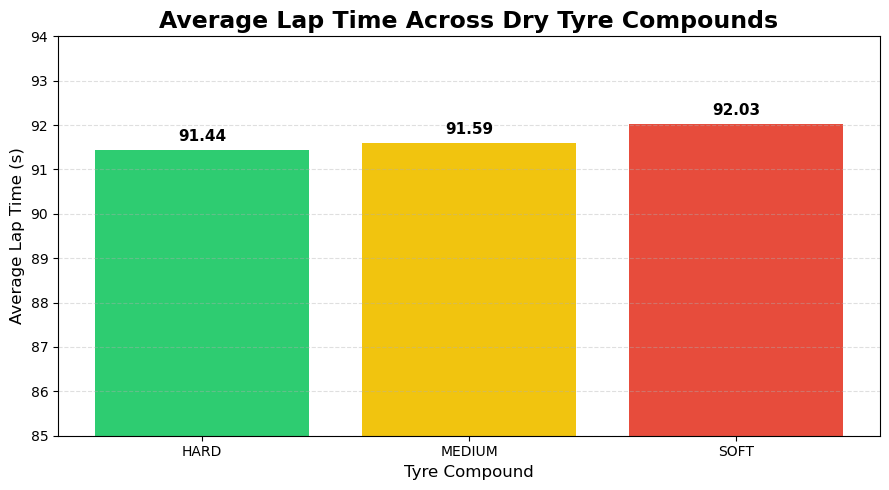

In [70]:
# Filtering dry tyre compounds
dry_compounds = f1_filtered[
    f1_filtered['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])
]

# Average lap time by dry compound
dry_compound_avg = (
    dry_compounds.groupby('Compound')['LapTime (s)']
    .mean()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(9,5))

colors = ['#2ECC71', '#F1C40F', '#E74C3C']

ax = plt.bar(
    dry_compound_avg['Compound'],
    dry_compound_avg['LapTime (s)'],
    color=colors
)

# Value labels
for bar in ax:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.2f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Average Lap Time Across Dry Tyre Compounds',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Tyre Compound', fontsize=12)
plt.ylabel('Average Lap Time (s)', fontsize=12)

plt.ylim(85, 94)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

## Which tyre provides the best balance between pace and durability?

Comparing Tyre Degradation Across Dry Compounds

Average lap time alone does not fully explain tyre strategy in Formula 1. Teams must also understand how tyre performance changes throughout a race stint.

Different tyre compounds are designed with different trade-offs:

* SOFT tyres generally provide higher pace but may degrade faster
* HARD tyres are expected to offer greater durability and consistency
* MEDIUM tyres attempt to balance both speed and longevity

To better understand these degradation patterns, tyre life is grouped into broader stint phases and compared across dry tyre compounds.

In [75]:
import warnings
warnings.filterwarnings('ignore')

In [76]:
# Filtering dry tyre compounds
dry_compounds = f1_filtered[
    f1_filtered['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])
].copy()

# Creating tyre life stages
dry_compounds['Tyre_Stage'] = pd.cut(
    dry_compounds['TyreLife'],
    bins=[0,10,20,30,40,50],
    labels=[
        '0-10',
        '11-20',
        '21-30',
        '31-40',
        '41-50'
    ]
)


In [77]:
# Average lap time by tyre stage and compound
degradation_analysis = (
    dry_compounds.groupby(
        ['Tyre_Stage', 'Compound']
    )['LapTime (s)']
    .mean()
    .reset_index()
)


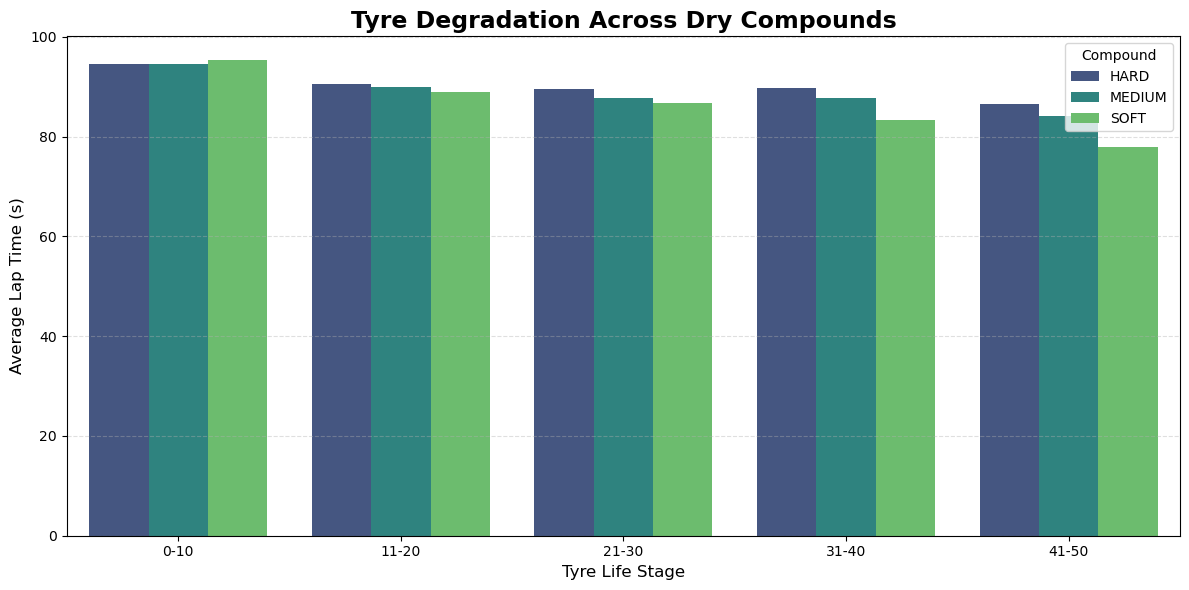

In [78]:
# Visualization
plt.figure(figsize=(12,6))

sns.barplot(
    data=degradation_analysis,
    x='Tyre_Stage',
    y='LapTime (s)',
    hue='Compound',
    palette='viridis'
)

plt.title(
    'Tyre Degradation Across Dry Compounds',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Tyre Life Stage', fontsize=12)
plt.ylabel('Average Lap Time (s)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

## Observation

The visualization shows that lap times generally decrease across later tyre life stages for all dry tyre compounds. Among the three compounds, SOFT tyres consistently maintain the lowest average lap times across most tyre stages, indicating stronger overall pace performance.

Hardtyres tend to show comparatively higher average lap times, while MEDIUM tyres remain positioned between SOFT and HARD compounds throughout the tyre life stages.

The chart also suggests that performance differences between compounds become more noticeable during later tyre stages, highlighting how tyre strategy can influence race pace over longer stints.